https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PSCompPars

Source for Dataset : NASA Exoplanet Archive - Planetary Systems Composite Parameters

In [3]:
import pandas as pd

df = pd.read_csv("NASA Exoplanet dataset.csv", comment='#')
df.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06000,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20000,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11000,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,0,1765.03890,1.67709,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,0,798.50000,1.00000,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


Planet radius, mass, surface temperature, orbital period, 
distance from star, Host star type, temperature, metallicity are present in the dataset

density, luminosity can be computed

Density = Mass / Volume

In [4]:
import numpy as np

EARTH_DENSITY = 5.51 

df["pl_density"] = (df["pl_bmasse"] / (df["pl_rade"]**3)) * EARTH_DENSITY


df[["pl_name", "pl_density"]].head()

,pl_name,pl_density
0,11 Com b,14.913743
1,11 UMi b,13.871666
2,14 And b,2.772416
3,14 Her b,7.050020
4,16 Cyg B b,1.266967


In [5]:
SUN_TEMP = 5772 
df["st_luminosity"] = (df["st_rad"]**2) * (df["st_teff"] / SUN_TEMP)**4
df[["pl_name", "st_luminosity"]].head()

,pl_name,st_luminosity
0,11 Com b,96.266166
1,11 UMi b,251.884564
2,14 And b,68.609376
3,14 Her b,0.632667
4,16 Cyg B b,1.257543


Schema of dataset

In [6]:
print("ROWS:", df.shape[0])
print("COLUMNS:", df.shape[1])
print("\nCOLUMN TYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())

ROWS: 6052
COLUMNS: 86

COLUMN TYPES:
 pl_name             object
hostname            object
sy_snum              int64
sy_pnum              int64
discoverymethod     object
                    ...   
sy_gaiamag         float64
sy_gaiamagerr1     float64
sy_gaiamagerr2     float64
pl_density         float64
st_luminosity      float64
Length: 86, dtype: object

MISSING VALUES:
 pl_name              0
hostname             0
sy_snum              0
sy_pnum              0
discoverymethod      0
                  ... 
sy_gaiamag         325
sy_gaiamagerr1     326
sy_gaiamagerr2     326
pl_density          49
st_luminosity      301
Length: 86, dtype: int64


Only the needed columns are extracted.
pl_name (ID column)
hostname (Star system name)
pl_rade → Planet radius
pl_bmasse → Planet mass
pl_density → (Computed density)
pl_eqt → Surface temperature (equilibrium temperature)
pl_orbper → Orbital period
pl_orbsmax → Distance from star (semi-major axis)
st_spectype → Star type
st_teff → Star temperature
st_met → Metallicity
st_luminosity → (Computed luminosity)

In [7]:
needed_columns = [
    "pl_name",
    "hostname",
    "pl_rade",
    "pl_bmasse",
    "pl_density",
    "pl_eqt",
    "pl_orbper",
    "pl_orbsmax",
    "st_spectype",
    "st_teff",
    "st_met",
    "st_luminosity"
]

df_main = df[needed_columns].copy()

df_main.head()


,pl_name,hostname,pl_rade,pl_bmasse,pl_density,pl_eqt,pl_orbper,pl_orbsmax,st_spectype,st_teff,st_met,st_luminosity
0,11 Com b,11 Com,12.2,4914.898486,14.913743,NaN,323.21000,1.178,G8 III,4874.0,-0.2600,96.266166
1,11 UMi b,11 UMi,12.3,4684.814200,13.871666,NaN,516.21997,1.530,K4 III,4213.0,-0.0200,251.884564
2,14 And b,14 And,13.1,1131.151301,2.772416,NaN,186.76000,0.775,K0 III,4888.0,-0.2100,68.609376
3,14 Her b,14 Her,12.6,2559.472162,7.050020,NaN,1765.03890,2.774,K0V,5338.0,0.4052,0.632667
4,16 Cyg B b,16 Cyg B,13.5,565.737400,1.266967,NaN,798.50000,1.660,G3 V,5750.0,0.0600,1.257543


In [8]:
#Handling missing values:
df_main.isnull().sum()

pl_name             0
hostname            0
pl_rade            25
pl_bmasse          31
pl_density         49
pl_eqt           1538
pl_orbper         315
pl_orbsmax        303
st_spectype      3821
st_teff           276
st_met            530
st_luminosity     301
dtype: int64

In [9]:
#Filling the numerical columns using Median
num_cols = ["pl_rade", "pl_bmasse", "pl_eqt", "pl_orbper",
            "pl_orbsmax", "st_teff", "st_met"]

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

df_main.loc[:, num_cols] = imputer.fit_transform(df_main[num_cols])


In [10]:
#Recalculating density 
EARTH_DENSITY = 5.51
df_main["pl_density"] = (df_main["pl_bmasse"] / (df_main["pl_rade"]**3)) * EARTH_DENSITY


In [11]:
#Recalculating Luminosity
SUN_TEMP = 5772
df_main["st_luminosity"] = (df_main["st_teff"] / SUN_TEMP)**4


In [12]:
#Filling Spectral Type using Mode -> Since it is categorical
df_main["st_spectype"] = df_main["st_spectype"].fillna(df_main["st_spectype"].mode()[0])


In [13]:
#Outlier removal
Q1 = df_main[num_cols].quantile(0.25)
Q3 = df_main[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_main = df_main[
    ~((df_main[num_cols] < (Q1 - 1.5 * IQR)) | 
      (df_main[num_cols] > (Q3 + 1.5 * IQR))
     ).any(axis=1)
]

In [14]:
#Handling inconsistent entries
df_main = df_main[
    (df_main["pl_rade"] > 0) &
    (df_main["pl_bmasse"] > 0) &
    (df_main["pl_eqt"] > 0) &
    (df_main["st_teff"] > 0) &
    (df_main["pl_orbper"] > 0)
]

In [15]:
#Categorical column -> st_spectype (Star Type)
#Let us perform One Hot Encoding on this column
df_main = pd.get_dummies(df_main, columns=["st_spectype"], prefix="star", drop_first=True)


In [16]:
# Lets check for missing values again
df_main.isna().sum()


pl_name        0
hostname       0
pl_rade        0
pl_bmasse      0
pl_density     0
              ..
star_M3.0      0
star_M3.0 V    0
star_M4        0
star_M4 V      0
star_M5.0 V    0
Length: 158, dtype: int64

In [17]:
#HABITABILITY SCORE INDEX
from sklearn.preprocessing import MinMaxScaler

habitability_features = [
    "pl_rade",
    "pl_density",
    "pl_eqt",
    "pl_orbsmax"
]

scaler = MinMaxScaler()

df_main[habitability_features] = scaler.fit_transform(
    df_main[habitability_features]
)

df_main["habitability_score"] = (
    0.30 * (1 - abs(df_main["pl_rade"] - 0.5)) +
    0.30 * (1 - abs(df_main["pl_density"] - 0.5)) +
    0.25 * (1 - abs(df_main["pl_eqt"] - 0.5)) +
    0.15 * (1 - abs(df_main["pl_orbsmax"] - 0.5))
)


In [19]:
#STELLAR COMPATABILITY INDEX
stellar_features = ["st_teff", "st_met", "st_luminosity"]

df_main[stellar_features] = scaler.fit_transform(
    df_main[stellar_features]
)

df_main["stellar_compatibility_index"] = (
    0.4 * (1 - abs(df_main["st_teff"] - 0.5)) +
    0.3 * df_main["st_met"] +
    0.3 * (1 - abs(df_main["st_luminosity"] - 0.5))
)


In [20]:
#Normalizing numerical features
exclude_cols = ["pl_name", "hostname"]
num_cols_final = df_main.select_dtypes(include=["float64", "int64"]).columns

scaler = MinMaxScaler()
df_main[num_cols_final] = scaler.fit_transform(df_main[num_cols_final])


In [ ]:
#Data Quality Validation

In [21]:
df_main.describe()


,pl_rade,pl_bmasse,pl_density,pl_eqt,pl_orbper,pl_orbsmax,st_teff,st_met,st_luminosity,habitability_score,stellar_compatibility_index
count,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000,3643.000000
mean,0.139017,0.066997,0.001654,0.458755,0.184584,0.176175,0.517851,0.492523,0.319142,0.427875,0.650549
std,0.150102,0.155894,0.017742,0.213189,0.190130,0.122893,0.192266,0.190641,0.162832,0.149832,0.174365
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.056119,0.007878,0.000501,0.300604,0.054959,0.086236,0.417559,0.384921,0.202630,0.340072,0.571060
50%,0.087583,0.014794,0.000804,0.440332,0.114304,0.147883,0.564825,0.490741,0.333181,0.424467,0.688075
75%,0.126806,0.028236,0.001334,0.588369,0.236143,0.220902,0.653185,0.608466,0.431406,0.494747,0.758150
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


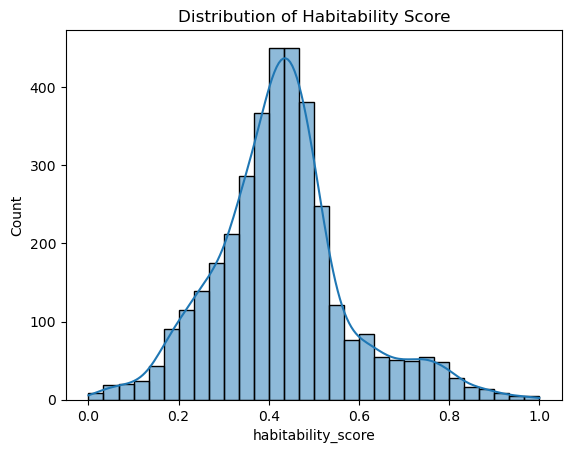

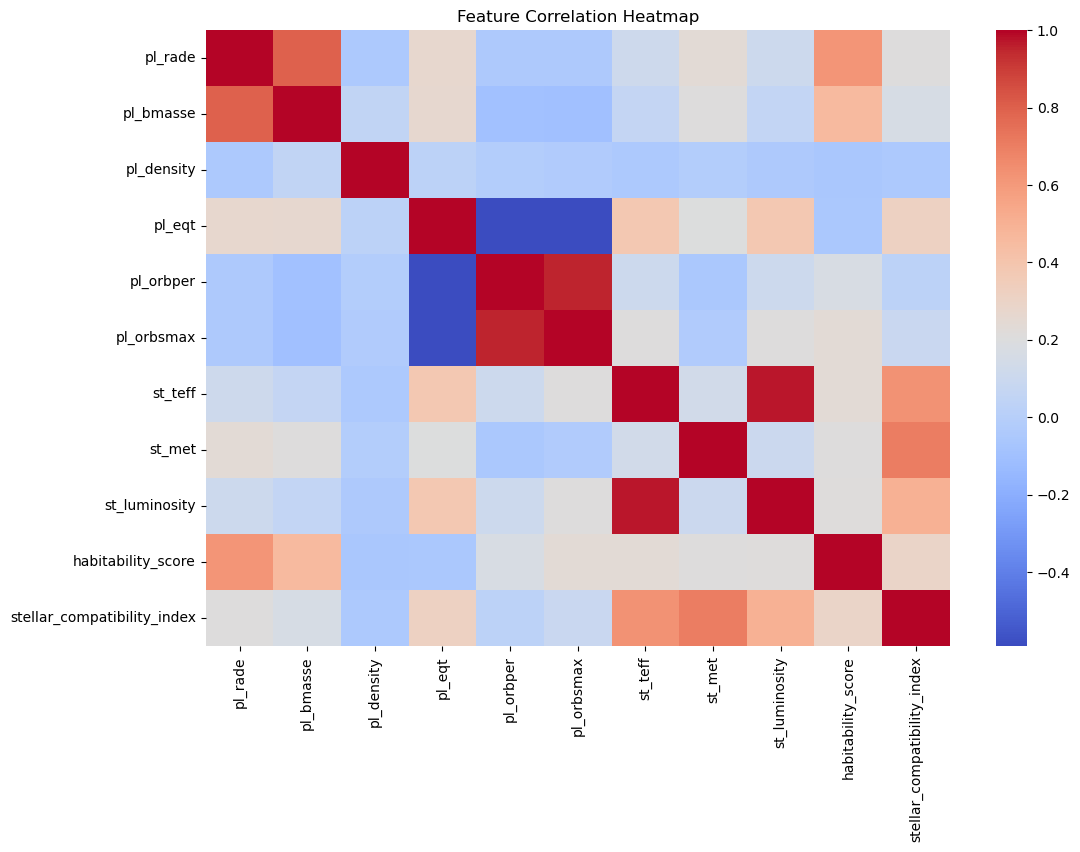

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Habitability Score
sns.histplot(df_main["habitability_score"], bins=30, kde=True)
plt.title("Distribution of Habitability Score")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    df_main[num_cols_final].corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.show()
